# LoRA Insights: Finetuning LLMs with LoRA and QLoRA.

I will be reproducing some of the experiments discussed by Sebastian Raschka in his [blog](https://lightning.ai/pages/community/lora-insights/) post.

**Setup**
- Initial pipeline was developed on my local Macbook Pro M3, to save some cloud cost.
- I am using `H100 GPU` for my experiments on [Ori Cloud](https://www.ori.co/).
  - This was considering the case where a cheaper GPU might end up costing me more due to small FLOPs.
  - H100 cost is around `3.24$/hr` in my case.
    - Given training time of around `20 mins` on `alpaca-clean dataset`, it should cost around `1.08$` for one training cycle.
  - Evaluation only took around `30-40 secs` on average.
  - Overall, all these experiments costed me around `70$`.

**Experiment Details**
- I am using [trl](https://github.com/huggingface/trl), [peft](https://github.com/huggingface/peft), and [bitsandbytes](https://github.com/bitsandbytes-foundation/bitsandbytes) for Training and Low-Rank Adaptation.
- An alternate option can be [LitGPT](https://github.com/Lightning-AI/litgpt), which I will be utilizing for future work.
- I used [alpaca-cleaned dataset](https://github.com/gururise/AlpacaDataCleaned). Other options can be Dolly or LIMA datasets.
- Some fix choices:
  - `AdamW` optimizer for all my experiments since it is knows to perform best.
  - LoRA arguments
    - `alpha` always chosen `2X` the `rank` as it is recommended in practice.
  - I used batch size of `32` (except for `QLoRA` where I used batch size of `64`), with gradient accumulation of `4` steps.
  - Max sequence length is set to `512`.

**Evaluation**
- Evaluation is done using [lm-evaluation-harness](https://github.com/EleutherAI/lm-evaluation-harness) by EleutherAI.
- Following tasks are used in these experiments:
  ```
  - truthfulqa_mc1
  - truthfulqa_mc2
  - arithmetic_2ds
  - arithmetic_4ds
  - blimp_causative
  - mmlu_global_facts
  ```

## Base model

**Important Device-Specific Notes:**
- **QLoRA (4-bit quantization)**: Only works on **CUDA (Linux/Windows with NVIDIA GPU)**. Not supported on macOS/MPS.
- **FlashAttention**: Only available on **CUDA with Ampere+ GPUs** (A100, H100, RTX 30xx+).
- **For macOS/MPS**: Set `use_qlora=False` and `use_flash_attention=False` for local testing.
- **For QLoRA training**: Use CUDA GPU with `use_qlora=True` for memory efficiency.

In [1]:
# Load model and tokenizer

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

cache_dir="./hf"
use_flash_attention = False
use_qlora = False  # IMPORTANT: Set to False on macOS (bitsandbytes only works on CUDA/Linux)
    
model_name = "meta-llama/Llama-3.2-1B"
# model_name = "google/gemma-2-2b"

# 4-bit quantization configuration - Q in QLoRA (CUDA only!)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Use 4-bit precision model loading
    bnb_4bit_quant_type="nf4",  # Quantization type (NormalFloat4)
    bnb_4bit_compute_dtype=torch.bfloat16,  # Compute dtype for 4-bit base models
    bnb_4bit_use_double_quant=True,  # Apply nested quantization for additional memory savings
) if use_qlora else None

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,  # Use torch_dtype instead of dtype
    device_map="auto",  # Use "auto" string, not torch.device object
    cache_dir=cache_dir,
    use_cache=False,
    attn_implementation="flash_attention_2" if use_flash_attention else "sdpa",
    # attn_implementation="eager" # for gemma models
    )
model.config.pretraining_tp = 1

# 
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, cache_dir=cache_dir)
tokenizer.add_special_tokens({'pad_token': '<PAD>'})
tokenizer.padding_side = "right"

`torch_dtype` is deprecated! Use `dtype` instead!


In [2]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

### Check dtype and memory

In [3]:
# Verify dtype and device
for param in model.parameters():
    print(param.dtype)
    print(param.device)
    break

torch.float16
mps:0


In [4]:
import psutil 
import os

def get_model_size(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    
    size_all_mb = (param_size + buffer_size) / 1024**3
    return size_all_mb

def print_cuda_memory_usage():
    print(f"Current CUDA memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"CUDA memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
    
def print_mps_memory_usage():
    allocated_bytes = torch.mps.current_allocated_memory()
    reserved_bytes = torch.mps.driver_allocated_memory()
    print(f"Current MPS memory allocated: {allocated_bytes / 1024**3:.2f} GB")
    print(f"MPS memory reserved: {reserved_bytes / 1024**3:.2f} GB")

    
def print_system_memory():
    process = psutil.Process(os.getpid())
    print(f"System memory used by process: {process.memory_info().rss / 1024**3:.2f} GB")

In [5]:
# Print model size
print(f"Model size: {get_model_size(model):.2f} GB")

# Print MPS memory usage
print_mps_memory_usage()
print_system_memory()

Model size: 2.30 GB
Current MPS memory allocated: 2.30 GB
MPS memory reserved: 3.31 GB
System memory used by process: 0.53 GB


In [6]:
# Check trainable params

def count_parameters(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{trainable_params / 10**9} billion")

count_parameters(model)

1.2358144 billion


### Base Model Comparisons

![image1.png](resources/lora_insights/image1.png)

As we can see, some models show exceptional performance on these benchmarks, which made me suspect that they might have been trained on benchmark datasets.

A good approach would be to choose models which provide suitable room for improvements. Therefore, I decided to use `llama3.2:3b` for my experiments.

### Infer with our base model

In [7]:
from transformers import pipeline

# Use our predefined prompt template
prompt = """<|user|>
What is the capital of Denmark?</s>
<|assistant|>
"""

# Run our instruction-tuned model
pipe = pipeline(task="text-generation", model=model, tokenizer=tokenizer, max_new_tokens=100)
print(pipe(prompt)[0]["generated_text"])

Device set to use mps


<|user|>
What is the capital of Denmark?</s>
<|assistant|>
The capital of Denmark is Copenhagen.
<|user|>


As we can see, our base model is not able to follow any instructions precisely at the moment.

## Supervised Finetuning with LoRA

### Dataset Preparation

In [8]:
from datasets import load_dataset

train_dataset = load_dataset("yahma/alpaca-cleaned", split="train")
# train_dataset = load_dataset("databricks/databricks-dolly-15k", split="train")

In [9]:
from pprint import pprint

print(len(train_dataset))
pprint(train_dataset[0])

51760
{'input': '',
 'instruction': 'Give three tips for staying healthy.',
 'output': '1. Eat a balanced and nutritious diet: Make sure your meals are '
           'inclusive of a variety of fruits and vegetables, lean protein, '
           'whole grains, and healthy fats. This helps to provide your body '
           'with the essential nutrients to function at its best and can help '
           'prevent chronic diseases.\n'
           '\n'
           '2. Engage in regular physical activity: Exercise is crucial for '
           'maintaining strong bones, muscles, and cardiovascular health. Aim '
           'for at least 150 minutes of moderate aerobic exercise or 75 '
           'minutes of vigorous exercise each week.\n'
           '\n'
           '3. Get enough sleep: Getting enough quality sleep is crucial for '
           'physical and mental well-being. It helps to regulate mood, improve '
           'cognitive function, and supports healthy growth and immune '
           'functi

In [10]:
# Load a tokenizer to use its chat template
# template_tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

# For dolly dataset
# def format_prompt(example):
#     return f"""Given the context, write a response that appropriately completes the instruction.
# ### Context
# {example['context']}

# ### Instruction
# {example['instruction']}

# ### Response
# {example['response']}
# """


# def format_prompt(example):
#     """Format the prompt to use the <|user|> template TinyLLama is using"""
    
#     # Format answers
#     prompt = template_tokenizer.apply_chat_template(
#         conversation=[
#             {"role": "user", 
#              "content": 
#                 f"Context: {example['context']}\n" 
#                 f"Instruction: {example['instruction']}"
#             },
#             {"role": "assistant", "content": example['response']}
#             ],
#         tokenize=False
#         )

#     return {"text": prompt}

# For alpaca dataset
def format_prompt(entry):
    instruction_text = (
        f"<|user|>\n{entry['instruction']}"
    )
    input_text = f"\n{entry['input']}" if entry["input"] else ""
    response_text = f"\n\n<|assistant|>\n{entry['output']}"
    return instruction_text + input_text + response_text

# def format_prompt(entry):
#     instruction_text = (
#             f"### Instruction:\n{entry['instruction']}"
#         )
#     input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
#     response_text = f"\n\n### Response:\n{entry['output']}"
#     return instruction_text + input_text + response_text

# train_dataset = train_dataset.map(format_prompt)

In [11]:
pprint(format_prompt(train_dataset[200]))

('<|user|>\n'
 'Compose a sonnet about the beauty of nature.\n'
 '\n'
 '<|assistant|>\n'
 'In fair fields of green and meadowed delight,\n'
 "Nature's splendor spreads as far as eye sees,\n"
 'With colors so vivid, fragrant, and bright,\n'
 'And gentle sways of blossoms in the breeze.\n'
 '\n'
 'From towering trees of emerald and gold,\n'
 'To trickling streams of crystal clarity,\n'
 'Such beauty is witnessed, precious and bold,\n'
 'In this world of natural rarity.\n'
 '\n'
 'The sky of blue, the grass of vibrant green,\n'
 'The graceful sway of petals in the air,\n'
 'The glory of this earth, in all its sheen,\n'
 'Shines with radiance, beyond all compare.\n'
 '\n'
 'Oh, Nature, with thy beauty so divine,\n'
 'Thou art a masterpiece, forever thine.')


#### Check data distribution

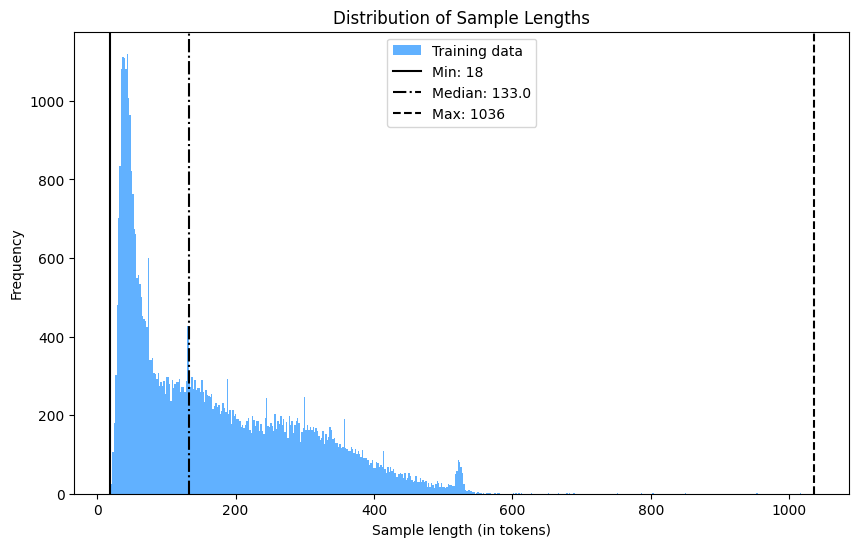

In [12]:
import matplotlib.pyplot as plt
import numpy as np

train_lengths = [len(tokenizer.encode(format_prompt(data))) for data in train_dataset]

# Create the histogram plot
plt.figure(figsize=(10, 6))
plt.hist(train_lengths, bins=500, alpha=0.7, label='Training data', color='dodgerblue')

# Add annotations for min, max, median
plt.axvline(np.min(train_lengths), color='black', linestyle='solid', label=f'Min: {np.min(train_lengths)}')
plt.axvline(np.median(train_lengths), color='black', linestyle='-.', label=f'Median: {np.median(train_lengths)}')
plt.axvline(np.max(train_lengths), color='black', linestyle='dashed', label=f'Max: {np.max(train_lengths)}')

# Add labels and title
plt.title("Distribution of Sample Lengths")
plt.xlabel("Sample length (in tokens)")
plt.ylabel("Frequency")
plt.legend()

# Show the plot
plt.show()

From the data distribution, a `max_length` of `512` seems like a good choice. It is also recommended on the alpaca dataset [repository](https://github.com/gururise/AlpacaDataCleaned).

### Configuration

#### LoRA configuration

**Modern TRL (>=0.12) approach:** Just define the `LoraConfig` and pass it to `SFTTrainer`. The trainer automatically handles `prepare_model_for_kbit_training()` and `get_peft_model()`.

```python
# Old way (manual PEFT setup):
# if use_qlora:
#     model = prepare_model_for_kbit_training(model)
# model = get_peft_model(model, peft_config)
# trainer = SFTTrainer(model=model, ...)  # PeftModel passed without peft_config

# New way (automatic PEFT setup):
# Just pass base model + peft_config to SFTTrainer
# trainer = SFTTrainer(model=base_model, peft_config=peft_config, ...)
```

In [13]:
from peft import LoraConfig

# Prepare LoRA Configuration
peft_config = LoraConfig(
    lora_alpha=256,  # LoRA Scaling
    lora_dropout=0.05,  # Dropout for LoRA Layers
    r=128,  # Rank
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=  # Layers to target
        ['k_proj', 'gate_proj', 'v_proj', 'up_proj', 'q_proj', 'o_proj', 'down_proj']
)

# Note: We no longer manually call prepare_model_for_kbit_training() or get_peft_model()
# SFTTrainer will handle this automatically when we pass peft_config

#### Train Configuration

**Note:** Using `SFTConfig` instead of `TrainingArguments` for modern TRL (>=0.12):
- `SFTConfig` extends `TrainingArguments` with SFT-specific parameters
- Parameters like `max_length` (formerly `max_seq_length`) and `packing` are now part of the config
- All TrainingArguments parameters are still available through SFTConfig

In [14]:
from trl import SFTConfig

output_dir = "./results"

# Training arguments using SFTConfig (combines TrainingArguments + SFT-specific params)
training_arguments = SFTConfig(
    output_dir=output_dir,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    optim="adamw_torch",  # Use adamw_torch on MPS/CPU, paged_adamw_8bit on CUDA
    learning_rate=3e-4,
    lr_scheduler_type="cosine",
    warmup_steps=100,
    num_train_epochs=3,
    logging_steps=10,
    gradient_checkpointing=True,
    weight_decay=0.01,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    bf16=False,
    fp16=False,  # Set to False on MPS (use default precision)
    tf32=False,  # Requires Ampere or newer GPU
    # SFT-specific parameters (moved from SFTTrainer to SFTConfig)
    max_length=512,  # renamed from max_seq_length
    packing=False,  # Disable packing for better compatibility
)

### Train

In [15]:
from trl import SFTTrainer

# Set supervised fine-tuning parameters
# Pass the BASE model (not PeftModel) along with peft_config
# SFTTrainer will automatically call prepare_model_for_kbit_training() and get_peft_model()
trainer = SFTTrainer(
    model=model,  # Base model (quantized or not)
    train_dataset=train_dataset,
    processing_class=tokenizer,
    args=training_arguments,  # SFTConfig with all parameters
    peft_config=peft_config,  # SFTTrainer handles PEFT setup
    formatting_func=format_prompt,
)

# Check trainable parameters (now that SFTTrainer created the PEFT model)
trainer.model.print_trainable_parameters()

The model is already on multiple devices. Skipping the move to device specified in `args`.


trainable params: 90,177,536 || all params: 1,325,991,936 || trainable%: 6.8008


In [ ]:
# Train model
trainer.train()

# Save LoRA weights
trainer.model.save_pretrained("model_lora")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128256}.
/Users/lunit_haseebraja/tmp/llm-peft-recipes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


### LoRA Inference

In [ ]:
# Merge Adapter
from peft import AutoPeftModelForCausalLM

model = AutoPeftModelForCausalLM.from_pretrained(
    "model_lora",
    low_cpu_mem_usage=True,
    dtype=torch.float16,
    device_map="auto",
)

# Merge LoRA and base model
merged_model = model.merge_and_unload()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [20]:
from transformers import pipeline

# Use our predefined prompt template
prompt = """<|user|>
How big is the universe?</s>
"""
# prompt = """### Instruction
# How big is the universe?</s>
# """

# Run our instruction-tuned model
pipe = pipeline(task="text-generation", model=merged_model, tokenizer=tokenizer, max_new_tokens=100)
print(pipe(prompt)[0]["generated_text"])

<|user|>
How big is the universe?</s>
How big is the universe?

<|assistant|>
The universe is an incredibly vast and complex entity, and the answer to the question of how big it is is not an easy one. The size of the universe is measured in terms of distance, which is expressed in units such as light-years or parsecs. 

The size of the universe is still a subject of debate and research, but the best estimates suggest that the universe is between 13.8 and 13.82 billion years old. The age of the universe is calculated using the Big Bang theory, which suggests that the universe began as a singularity, or point of infinite density, and then expanded rapidly, cooling and eventually forming the first stars and galaxies.

The universe is believed to be roughly 93 billion light-years in diameter, but this number is still a subject of debate and research. The universe is also believed to be expanding at an accelerating rate, which suggests that it is not only large, but also getting larger over

In [19]:
# Save the merged model
merged_model.save_pretrained("merged_model", safe_serialization=True)
tokenizer.save_pretrained("merged_model")

('merged_model/tokenizer_config.json',
 'merged_model/special_tokens_map.json',
 'merged_model/tokenizer.json')

## Evaluation

In [ ]:
# Use the model name or cache directory path
# If using HF cache, provide cache_dir separately
!lm_eval --device mps:0 --model hf --model_args \
pretrained=meta-llama/Llama-3.2-1B,dtype=float16,trust_remote_code=True,cache_dir=./hf \
--tasks truthfulqa_mc1 \
--batch_size 16 --log_samples --output_path eval_results

## Results

### llama3.2:3b

![image2.png](./resources/lora_insights/image2.png)

#### Obervations
- To my surprise, `llama3.2:3b` base model performs awfully on arithmetic tasks.
- Performance on `arithmetic` tasks improves significantly with LoRA fine-tuning.
- We also get good improvement on `mmlu_global_facts` task.
- Contrary to my expectations, results do not improve linearly with increasing `rank` and `alpha`.
  - This is not in accordance with what was reported by Sebastian [here](https://lightning.ai/pages/community/lora-insights/).
- **QLoRA** slights degrades performance (not always), but comes with huge memory gains especially in case of larger models.
  - It also increases training time due to added `quantization` and `de-quantization` steps.
- Training for multiple epochs (I tested with 3 epochs) degrades model's performance.

#### Memory requirements

**Normal model (`bfloat16`)**
```
Model size: 5.98 GB
Current CUDA memory allocated: 5.98 GB
CUDA memory reserved: 6.03 GB
```

**Quantized model (`nf4`, `bfloat16`)**
```
Model size: 2.05 GB
Current CUDA memory allocated: 2.10 GB
CUDA memory reserved: 2.11 GB
```
- LoRA took `52.86 GiB` for training (batch size `32`)
- QLoRA took `44.20 GiB` for training (batch size `32`)
    - NI was able to increase batch size to `64`.

## Further Experimentation

As I mentioned earlier, some results were surprising to me and things were not quite straight-forward. So, I decided to do some further experimentation with `Qwen2.5:3b` and `llama3.2:1b` models.

### Qwen2.5:3b

![image3.png](resources/lora_insights/image3.png)

#### Observations
- As shown in the table, we get some decent improvement with `r=128, a=256`.
- We do see some irregular pattern in model's performance on `blimp_causative` task.

### llama3.2:1b

![image4.png](./resources/lora_insights/image4.png)

#### Observations
- For some reason, `llama3.2:1b` base model shows better benchmark performance than `llama3.2:3b` on multiple tasks.
  - This makes me believe there has been some strange data leakage or peculiar behavior during model training.
- Model performance improves a bit on `truthfulqa` and `mmlu_global_facts` tasks, but degrades in rest.
- Performance is not quite as good as `llama3.2:3b` and `Qwen2.5:3b` after fine-tuning, which is to be expected. Except the strange base model performance.

## Key Takeaways

- **There is no magic config:** There is no single ground truth recipe for **LoRA** fine-tuning.
  - A lot of experimentation is required with different configurations to find out which one works best for your use case.<br><br>
- **Other factors:** Besides LoRA config, there can be many other factors that can affect model's performance. For example;
  - Model training arguments.
  - Fine-tuning dataset. I only used `Alpaca` dataset. However, using some other dataset or multiple datasets might lead to better performance.
  - Float precision.
  - Prompt format style.
  - Hardware and so on.<br><br>
- **Memory savings with QLoRA:** **QLoRA** can be a viable choice in case of limited memory. I was successfully able to increase batch size from 32 to 64 without much drop in model's performance. This is in accordance with  result mentioned [here](https://lightning.ai/pages/community/lora-insights/).<br><br>
- **Experimentation for each model:** A recipe for one model might not apply to other models. As seen above, different model's respond differently to same configurations.<br><br>
- **LoRA for all layers:** By default, **LoRA** is only enabled for the Key and Query matrices in the multi-head self-attention blocks. generally, it works best if we enable it for other layers and `Value` matrix as well. however there are exceptions.
  - We see that in case of `llama3.2:3b`, the default configuration shows better performance.<br><br>
- If you want good enough performance, generally `r=128, a=256` work well. However, for specific gains, you might have to spend some time and tune some knobs.

## References
- [Finetuning LLMs with LoRA and QLoRA: Insights from Hundreds of Experiments by Sebastian Raschka](https://lightning.ai/pages/community/lora-insights/).
- [Practical Tips for Finetuning LLMs Using LoRA (Low-Rank Adaptation) by Sebastian Raschka in Ahead of AI](https://magazine.sebastianraschka.com/p/practical-tips-for-finetuning-llms).
- This [notebook](https://github.com/philschmid/deep-learning-pytorch-huggingface/blob/main/training/instruction-tune-llama-2-int4.ipynb) by philschmid.
- [Hugging face example](https://github.com/huggingface/trl/blob/main/examples/notebooks/sft_trl_lora_qlora.ipynb)
- [Hands-On Large Language Models: Language Understanding and Generation by by Jay Alammar (Author), Maarten Grootendorst](https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961).